In [205]:
import numpy as np
import sympy as smp
import qiskit 
from qiskit.circuit import QuantumRegister, QuantumCircuit, Parameter
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

import matplotlib.pyplot as plt

from functools import reduce

import pandas as pd

import scipy.optimize as opt

In [206]:
n_qubits = 10
zeta = 0
eta = 0
J = 0.1

I2 = np.eye(2)
I = np.eye(2**n_qubits)

X = np.array([
    [0, 1], 
    [1, 0]
])
Z = np.array([
    [1, 0],
    [0, -1]
])
H = np.array([
    [1, 1],
    [1, -1]
]) / np.sqrt(2)

def GateJ(n=n_qubits, j=0, gate=X):
    curr = I2 if j != 0 else gate
    # print(curr)
    for qubit in range(1, n):
        # if qubit==0: continue;
        # print(f"qubit: {qubit}")
        
        if qubit == j:
            curr = np.kron(gate, curr)
            # print('kron X')
            continue
        curr = np.kron(I2, curr)
        # print('kron I')

    return curr

GateJ(n_qubits, 7, H).shape == (1024,1024)

True

$A = \frac{1}{\zeta} ( \sum_{j=1}^{n} X_j + J \sum_{j=1}^{n-1} Z_j Z_{j+1} + \eta I)$

$| b \rangle = H^{\otimes n} | 0 \rangle$

In [207]:
# calculate first two terms of A (no zeta or eta)
Xsum = np.zeros(shape=(2**n_qubits, 2**n_qubits))
Zsum = np.zeros(shape=(2**n_qubits, 2**n_qubits))
for j in range(0, n_qubits):
    # print(j)
    Xsum += GateJ(j=j)

    if j != n_qubits-1:
        Zsum += GateJ(j=j, gate=Z) @ GateJ(j=j+1, gate=Z)

Zsum *= J
M = Xsum + Zsum

eigenvals = np.linalg.eigvals(M)

In [208]:
κ = 60 # condition number for n=10 qubits

η, ζ = smp.symbols("η ζ")

λmin = min(eigenvals)
λmax = max(eigenvals)

A0 = λmin + η - (ζ / κ)
A1 = λmax + η - ζ

soln = smp.solve([A0, A1], [η, ζ])
eta = float(soln[η])
zeta = float(soln[ζ])
soln

{ζ: 20.3847680482924, η: 10.3622570912153}

In [209]:
A = (M + eta * I) / zeta
A

array([[0.55248395, 0.04905624, 0.04905624, ..., 0.        , 0.        ,
        0.        ],
       [0.04905624, 0.5426727 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04905624, 0.        , 0.53286145, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.53286145, 0.        ,
        0.04905624],
       [0.        , 0.        , 0.        , ..., 0.        , 0.5426727 ,
        0.04905624],
       [0.        , 0.        , 0.        , ..., 0.04905624, 0.04905624,
        0.55248395]], shape=(1024, 1024))

To scale from 3->10 qubits, we need 3 layers:
* Hardware-efficient ansatz
* Layered controlled A gates
* controlled U gate ($H^{\otimes n} | 0 \rangle $)

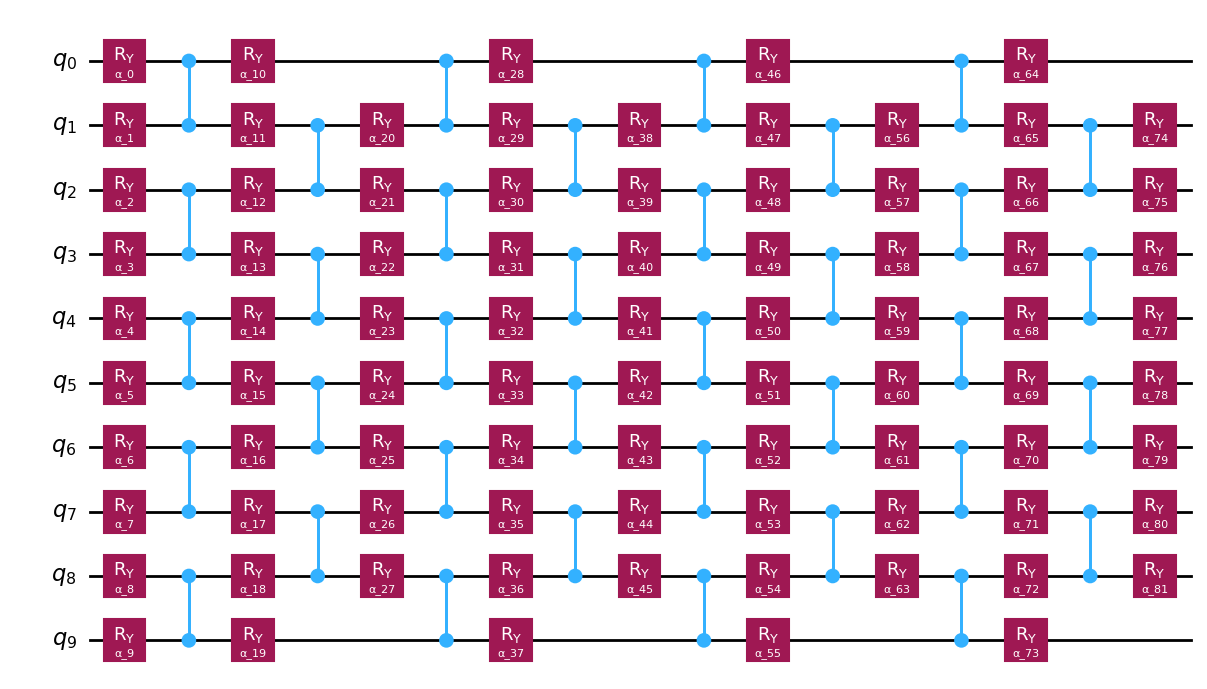

In [210]:
ancilla_idx = n_qubits

# U_b gate
Ub = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    Ub.h(i)

# ansatz

def variational_form(n_qubits: int=10, layers: int=4):
    # init rot layer
    num_params = n_qubits
    # per layer
    num_params += n_qubits * layers # per full rotational layer
    num_params += (n_qubits - 2) * layers # per alternating rotational layer

    α = [Parameter(f"α_{i}") for i in range(num_params)]

    v = QuantumCircuit(n_qubits)

    # initial rotational layer
    param = 0
    for qubit in range(n_qubits):
        v.ry(α[param], qubit) # first ten parameters
        param += 1

    for layer in range(layers):
        # entangling layer between adjacent pairs of qubits
        for qubit in range(0, n_qubits-1, 2):
            v.cz(qubit, qubit + 1)

        # v.barrier()

        # rotation layer
        for qubit in range(n_qubits):
            v.ry(α[param], qubit)
            param += 1

        # entangling layer between alternating pairs of qubits
        for qubit in range(1, n_qubits-2, 2):
            v.cz(qubit, qubit+1)

        # rotational layer for alternating pairs
        for qubit in range(1, n_qubits-1):
            v.ry(α[param], qubit)
            param += 1

    # print(param, v.num_parameters)

    return v, α

variational_form(n_qubits=10, layers=4)[0].draw('mpl')

In [211]:
# controlled A gate

def build_A_terms(l, n_qubits=10):
    coefficients = 0
    operations = []

    if l == 0:
        coefficients = eta / zeta # eta / zeta
        operations.append(("I", 0))

    if l >= 1  and l <= n_qubits:
        coefficients = 1 / zeta # 1 / zeta
        operations.append(("X", l-1)) 

    if l >= n_qubits + 1 and l <= (2 * n_qubits - 1):
        coefficients = J / zeta # J / zeta
        operations.append(("Z", l-n_qubits-1))
        operations.append(("Z", l-n_qubits))

    return coefficients, operations

All $c_l$ and $A_l$ terms, aka $A = \sum c_l A_l$

In [212]:
c = []

for l in range(2 * n_qubits - 1):
    co, _ = build_A_terms(l, n_qubits)
    c.append(co)
    print(build_A_terms(l, n_qubits))

print(c)

(0.5083333333333333, [('I', 0)])
(0.04905623638350735, [('X', 0)])
(0.04905623638350735, [('X', 1)])
(0.04905623638350735, [('X', 2)])
(0.04905623638350735, [('X', 3)])
(0.04905623638350735, [('X', 4)])
(0.04905623638350735, [('X', 5)])
(0.04905623638350735, [('X', 6)])
(0.04905623638350735, [('X', 7)])
(0.04905623638350735, [('X', 8)])
(0.04905623638350735, [('X', 9)])
(0.004905623638350735, [('Z', 0), ('Z', 1)])
(0.004905623638350735, [('Z', 1), ('Z', 2)])
(0.004905623638350735, [('Z', 2), ('Z', 3)])
(0.004905623638350735, [('Z', 3), ('Z', 4)])
(0.004905623638350735, [('Z', 4), ('Z', 5)])
(0.004905623638350735, [('Z', 5), ('Z', 6)])
(0.004905623638350735, [('Z', 6), ('Z', 7)])
(0.004905623638350735, [('Z', 7), ('Z', 8)])
[0.5083333333333333, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.004905623638350735, 0.004905623638

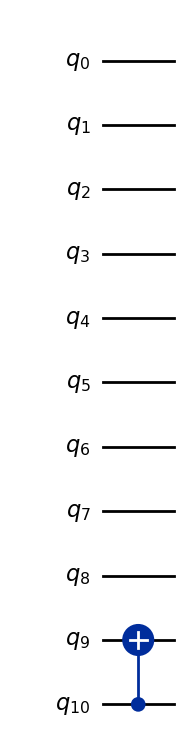

In [213]:
def controlled_A(i: int=0, n_qubits: int=10):
    A = QuantumCircuit(n_qubits + 1)

    _, ops = build_A_terms(i)
    # print(ops)
    for op, qubit in ops:
        match(op):
            case "I":
                pass
            case "X":
                A.cx(ancilla_idx, qubit)
            case "Z":
                A.cz(ancilla_idx, qubit)

    return A

controlled_A(10).draw('mpl')

In [214]:
# hadamard test
estimator = StatevectorEstimator()
V, _ = variational_form()
controlled_A_cache = [controlled_A(l) for l in range(2*n_qubits - 1)]

def local_hadamard_test(parameters: list=[], l: int=0, lp: int=0, j: int=0, part: str="real", n_qubits: int=10):
    system = QuantumRegister(n_qubits, name='q')
    ancilla = QuantumRegister(1, name='a')
    circuit = QuantumCircuit(system, ancilla)

    # first hadamard for the hadamard test
    circuit.h(ancilla_idx)

    if part.lower() == 'im':
        # phase shift by -pi/2
        θ = -np.pi / 2

        circuit.p(θ, ancilla_idx)

    # V, _ = variational_form()

    # apply ansatz
    circuit.compose(V, inplace=True)

    circuit.barrier()

    # A_l
    circuit.compose(controlled_A_cache[l], inplace=True)
    circuit.barrier()

    # typically would be the adjoint of U but U_dag = U in this case
    circuit.compose(Ub, inplace=True)
    circuit.barrier()

    if j != -1:
        circuit.cz(ancilla_idx, j)
    circuit.barrier()

    circuit.compose(Ub, inplace=True)
    circuit.barrier()

    circuit.compose(controlled_A_cache[lp], inplace=True)
    circuit.barrier()

    circuit.h(ancilla_idx)

    observables = [[SparsePauliOp(["ZIIIIIIIIII"])]]

    pub = (circuit, observables, parameters)
    job = estimator.run([pub])

    evs = job.result()[0].data.evs.squeeze()

    return evs, circuit

for l in range(2 * n_qubits - 1):
    evs, circuit = local_hadamard_test(np.zeros(82), l=l, lp=9, part='im')

    # display(circuit.draw('mpl'))
    print(f"l: {l}\nevs: {evs}")


l: 0
evs: -3.7300914504872254e-34
l: 1
evs: -3.7300914504872254e-34
l: 2
evs: -3.7300914504872254e-34
l: 3
evs: -3.6779389456346876e-34
l: 4
evs: -3.6522741142146352e-34
l: 5
evs: -1.8310894522720174e-34
l: 6
evs: -2.971945103954625e-34
l: 7
evs: -3.668666208878861e-34
l: 8
evs: -3.1598127725716734e-34
l: 9
evs: -8.77551699456539e-34
l: 10
evs: -3.4188221053968527e-34
l: 11
evs: -3.7300914504872254e-34
l: 12
evs: -3.7300914504872254e-34
l: 13
evs: -3.7300914504872254e-34
l: 14
evs: -3.7300914504872254e-34
l: 15
evs: -3.7300914504872254e-34
l: 16
evs: -3.7300914504872254e-34
l: 17
evs: -3.7300914504872254e-34
l: 18
evs: -3.7300914504872254e-34


In [215]:
# get the real and imaginary parts of μ 
def mu(weights, l: int=None, lp: int=None, j: int=None):
    mu_real = local_hadamard_test(weights, l=l, lp=lp, j=j, part='re')[0]
    mu_imag = local_hadamard_test(weights, l=l, lp=lp, j=j, part='im')[0]

    # display(circuit)

    return mu_real + 1.0j * mu_imag

In [216]:
L = 2 * n_qubits - 1

def mu_symmetric_sum(weights, j):
    total = 0.0 + 0.0j
    for l in range(L):
        for lp in range(l, L):
            val = mu(weights, l, lp, j)
            term_upper = c[l] * np.conj(c[lp]) * val
            if lp == l:
                total += term_upper
            else:
                term_lower = c[lp] * np.conj(c[l]) * np.conj(val)
                total += term_upper + term_lower
    return total

def norm(weights):
    return abs(mu_symmetric_sum(weights, -1))

def local_cost(weights):
    mu_sum = 0.0 + 0.0j
    for j in range(n_qubits):
        mu_sum += mu_symmetric_sum(weights, j)
    mu_sum = abs(mu_sum)
    return float(0.5 - 0.5 * mu_sum / (n_qubits * norm(weights)))

In [217]:
np.random.seed(12873)
α = 0.001 * np.random.randn(82)
α

array([ 2.45276491e-04,  9.78517289e-04, -1.16711228e-03,  5.74930634e-04,
        1.56642690e-03, -1.77631361e-04, -1.62350856e-04,  4.38960971e-04,
       -7.39666674e-04,  1.14431884e-03, -1.49825575e-03,  1.42476803e-03,
       -6.41049776e-04, -2.32473470e-04,  1.63941206e-03,  6.21804063e-04,
       -1.63904975e-04, -6.05533315e-04,  7.44847026e-04,  1.63721143e-04,
       -2.08407603e-04,  8.69687501e-04, -1.72340797e-03, -4.26655566e-04,
        6.69905658e-05, -1.76433599e-03, -1.98520004e-03,  1.42876827e-03,
        9.85102251e-05, -1.92806182e-04, -9.34231883e-05,  3.98420207e-04,
        1.32649612e-03,  1.75125457e-04,  2.40297988e-03,  8.54854361e-04,
       -6.70829275e-04,  2.36654148e-03,  9.11793503e-04,  9.13472899e-04,
       -3.29361179e-04,  9.04253554e-04,  6.88696524e-04, -1.15844520e-04,
       -7.26620701e-04, -3.91093227e-04, -2.53724045e-04, -4.07492677e-04,
       -3.10337637e-04,  8.38650738e-04, -8.87711694e-04,  1.41130164e-04,
       -1.40248664e-03, -

Custom minimization method needed:

For the Ising-inspired 10-qubit VQLS, the authors used an optimization method where in each iteration, a random direction w is chosen in the parameter space to perform a line search along, aka solving $$min_{s \in \mathbb{R}} C(\vec{\alpha} + s \hat{w})$$

In [ ]:
iterations = 100
history = []

for iter in range(iterations):
    w = np.random.randn(len(α))
    w /= np.linalg.norm(w)

    cost_bound = lambda s: local_cost(α + s * w)
    result = opt.minimize_scalar(cost_bound)

    s_new = result.x
    cost = result.fun

    α = α + s_new * w

    # cost = local_cost(α)
    history.append(cost)
    print(f"iter {iter:3d}   cost = {cost}")

plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("local_cost(α)")
plt.title(f"Random-direction line search, n_qubits={n_qubits}")
plt.show()